# Plateau’s Problem for Catenoid

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 
## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(5)
# torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [22]:
from util.visualization.utils_mesh import get_mesh

# Parametric equations for the catenoid in polar coordinates
def catenoid_surface_polar(v, u, c):
    x = c * torch.cosh(v / c) * torch.cos(u)
    y = c * torch.cosh(v / c) * torch.sin(u)
    z = v
    return x, y, z

# Level set function for the catenoid
def catenoid_level_set(x, c=0.7):
    x1 = x[:, 0]
    y1 = x[:, 1]
    z1 = x[:, 2]
    
    # Level set equation derived from the catenoid's implicit equation
    return x1**2 + y1**2 - (c**2 * torch.cosh(z1 / c)**2)

# Bounds and number of samples
n = 1000
u = torch.linspace(-torch.pi, torch.pi, n, dtype=torch.float64)
v_max = 1.0  # Adjust this to control the size of the catenoid
c = 0.7
v = torch.linspace(-v_max, v_max, n, dtype=torch.float64)

# Generate boundary points for the upper and lower circles
v_constant_upper = torch.full_like(u, v_max, dtype=torch.float64)  # Upper boundary circle at v_max
v_constant_lower = torch.full_like(u, -v_max, dtype=torch.float64)  # Lower boundary circle at v_min

# Compute points for the upper and lower circles
x_upper, y_upper, z_upper = catenoid_surface_polar(v_constant_upper, u, c)
x_lower, y_lower, z_lower = catenoid_surface_polar(v_constant_lower, u, c)

# Combine the points for both circles
pts_upper = torch.vstack([x_upper, y_upper, z_upper]).T
pts_lower = torch.vstack([x_lower, y_lower, z_lower]).T

# Concatenate the upper and lower boundary points
pts_boundary = torch.cat([pts_upper, pts_lower], dim=0)


# Generate the mesh using the level set function
verts, faces = get_mesh(
    lambda x: catenoid_level_set(x, c),  # Pass the level set with c=1.0
    N=128, 
    device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()


Output()

### Define the boundary rectangles

In [23]:
# pts_space = torch.rand([1000, 3], dtype=torch.float64)
# pts_space_fixed = torch.rand([1000, 3], dtype=torch.float64)
pts_space = 3 * torch.rand([1000, 3], dtype=torch.float64) - 1.5
# pts_space_fixed = 3 * torch.rand([1000, 3], dtype=torch.float64) - 1.5
# pts_space_fixed = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_eikonal = torch.cat((pts_space, pts_boundary))
# pts_eikonal = pts_boundary

# loss_weights = {"interface": 1.0, "eikonal": 0.001, "laplacian": 0.01, "curvature": 1.0}
# loss_weights = {"interface": 10.0, "eikonal": 0.001, "laplacian": 1.0, "curvature": 0.001}

# loss_weights = {"interface": 10.0, "eikonal": 0.001, "laplacian": 1.0, "curvature": 0.01}
# loss_weights = {"interface": 10.0, "eikonal": 0.01, "laplacian": 1.0, "curvature": 0.1}
# loss_weights = {"interface": 1.0, "eikonal": 1, "laplacian": 10.0}
# loss_weights = {"interface": 1.0, "eikonal": 0.001, "laplacian": 1.0}
loss_weights = {"interface": 10.0, "eikonal": 0.1, "curvature": 1.0}

# loss_weights = {"interface": 1.0, "eikonal": 0.001, "laplacian": 1.0}


config = {
    "pts_boundary": pts_boundary,
    "pts_eikonal": pts_eikonal,
    "pts_space": pts_space,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

model = GeneralNet(ks=[3, 32, 32, 1])
# model = GeneralNet(ks=[3, 50, 50, 1])
model = model.double()

### Point-sampler demo

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

### Main training loop

In [24]:
def sample_true_surface(n_samples, c):
    # Generate radial and angular coordinates
    r = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    phi = torch.linspace(-torch.pi, torch.pi, n_samples, dtype=torch.float64)
    
    # Create a grid of r and phi
    r, phi = torch.meshgrid(r, phi, indexing='ij')

    # Compute the x, y, z coordinates using the parametric equations
    x, y, z = catenoid_surface_polar(r.flatten(), phi.flatten(), c)
    points_on_surface = torch.vstack([x, y, z]).T

    return points_on_surface

def sample_model_surface(implicit_function, bounds, n_samples=128):
    x = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    y = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    z = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    
    xx, yy, zz = torch.meshgrid(x, y, z, indexing='ij')
    grid_points = torch.stack([xx.flatten(), yy.flatten(), zz.flatten()], dim=1)
    
    with torch.no_grad():
        values = implicit_function(grid_points).squeeze()
        mask = torch.isclose(values, torch.zeros_like(values), atol=1e-5)  # Adjust tolerance
        points_on_surface = grid_points[mask]
    
    return points_on_surface

def compute_distance(model, true_implicit, c):    

    # Sample points on the true implicit surface
    p_surface_true = sample_true_surface(64, c)
    p_surface_model = sample_model_surface(model, 128)

    # Compute the integral of squared values over both surfaces
    with torch.no_grad():
        model_surface_values = model(p_surface_true).squeeze().square()
        true_surface_values = true_implicit(p_surface_model, c).squeeze().square()

    d_model = model_surface_values.mean().sqrt()
    d_true = true_surface_values.mean().sqrt()
    # Combine into the distance metric
    distance = torch.sqrt(d_model**2 + d_true**2).item()

    return distance, p_surface_true, p_surface_model

# model = GeneralNet(ks=[3, 32, 32, 1])
# model = model.double()
distance, p_surface_true, p_surface_model = compute_distance(model.double(), catenoid_level_set, c)
print(f"Distance d(f_i, f_j): {distance}")


Distance d(f_i, f_j): nan


In [25]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(p_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

  0%|          | 0/1000 [00:00<?, ?it/s]

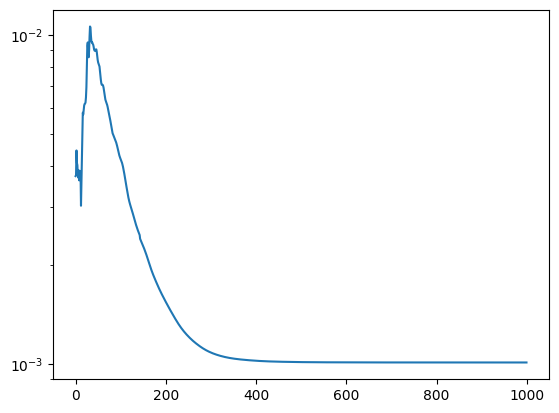

In [26]:
import time

# model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
params = model.params
loss_over_iters = {}
distance_over_iters = {}
# Gauss-Newton:
# loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.001, "laplacian": 1.0}
optim = HandNGD(model, lr=1e-2, config=config)
# Adam:
# loss_weights = {"interface": 10.0, "interface_corners": 0.0, "eikonal": 0.4, "laplacian": 1.0}
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik

for i in (pbar:=trange(1000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    # loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

    loss_curvature = 0.5*model.v_f_mean_curvature(params, pts_space).squeeze(1).square().mean()
       
    # loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian #+ loss_weights["curvature"] * loss_curvature
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["curvature"] * loss_curvature

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"curvature: {loss_curvature.item():.2e} "
                            # f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts_space)}"
                            )
        loss_over_iters[i] = loss_metric.item()
        # distance_over_iters[i], _, _ = compute_distance(model.double(), catenoid_level_set)
        # print(distance_over_iters[i])
        
    # optim.loss = loss_metric
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [27]:
distance, p_surface_true, p_surface_model = compute_distance(model.double(), catenoid_level_set, c)
print(f"Distance d(f_i, f_j): {distance}")

Distance d(f_i, f_j): 0.45398588532116646


In [28]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Visualize the result

In [92]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(p_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [83]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    catenoid_level_set, N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(p_surface_model.cpu().detach(), point_size=0.05)
fig.display()

Output()